<div style="text-align: center;">
  <img src="https://cdn.remotexs.co/institute-logos/uz.png"
       alt="University Logo"
       style="height:300px; width:auto; display: block; margin-left: auto; margin-right: auto; padding-bottom: 20px;">



## **UNIVERSITY OF ZIMBABWE**

### **STUDENT NAME:** LIBERTY NHONDORO
### **REGISTRATION NUMBER:** R2424989
### **COURSE CODE:** HASTS211
### **ASSIGNMENT:** ASSIGNMENT 3

---

## **Project Title:** Application Project 3 — Time Series Models
### **Topic:** Non-Stationarity, Cointegration & Equilibrium Modeling
</div>

# Application Project 3 — Time Series Models
## Topic: Non-Stationarity, Cointegration & Equilibrium Modeling
### Dataset: Apple Inc. (AAPL), Microsoft (MSFT), and NASDAQ-100 (QQQ) — Daily Prices (2018–2025)

---

> **Model Chosen:** Modeling Non-Stationarity and Finding an Equilibrium (Vector Error Correction Model / Johansen Cointegration)becouse 1.Financial Series Non-Stationarity: Individual financial price series like AAPL, MSFT, and QQQ are typically non-stationary ($I(1)$$I(1)$ processes), meaning their statistical properties change over time. VECM is designed for such series. (Refer to section '1.1 Non-Stationarity' and '1.3 Vector Error Correction Model (VECM)').
2.Expected Long-Run Equilibrium: Despite individual non-stationarity, economic theory suggests that these related assets (AAPL and MSFT as constituents of QQQ) should share common trends and maintain a long-run equilibrium relationship. Cointegration (tested by Johansen) helps detect this stable relationship. (Refer to section '1.2 Cointegration' and '2. Description' for more details on why these specific assets were chosen).
3.Modeling Both Short-Run Dynamics and Long-Run Equilibrium: The VECM not only identifies this long-run equilibrium but also quantifies how deviations from it are corrected over time (error correction mechanism) and how short-run changes interact.

---

## 0. Environment Setup — Install & Import Libraries

In [37]:
# Install required libraries (run once in Colab)
!pip install yfinance statsmodels pandas numpy matplotlib seaborn scipy --quiet

In [38]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Finance data ─────────────────────────────────────────────────────────────
import yfinance as yf

# ── Statistical tests ────────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_arch
import statsmodels.api as sm

from scipy import stats

# ── Formatting ───────────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

print('✅  All libraries loaded successfully.')

✅  All libraries loaded successfully.


---
## 1. Definition — Technical Formulation

### 1.1 Non-Stationarity
A time series $y_t$ is **non-stationary** if its statistical properties (mean, variance, autocovariance) depend on time. Formally, it fails the condition:

$$E[y_t] = \mu, \quad \operatorname{Var}(y_t) = \sigma^2, \quad \operatorname{Cov}(y_t, y_{t-k}) = \gamma_k \quad \forall\, t$$

An integrated series of order $d$, denoted $I(d)$, must be differenced $d$ times to achieve stationarity. For most financial price series:
$$P_t \sim I(1) \implies \Delta P_t = P_t - P_{t-1} \sim I(0)$$

### 1.2 Cointegration
Two or more $I(1)$ series $\mathbf{y}_t = (y_{1t}, y_{2t}, \ldots, y_{nt})'$ are **cointegrated** if there exists a vector $\boldsymbol{\beta}$ such that the linear combination:
$$z_t = \boldsymbol{\beta}' \mathbf{y}_t \sim I(0)$$

$z_t$ is the **equilibrium error** (or spread). It is stationary despite each individual series being $I(1)$.

### 1.3 Vector Error Correction Model (VECM)
The VECM captures both short-run dynamics and long-run equilibrium:

$$\Delta \mathbf{y}_t = \boldsymbol{\alpha} \boldsymbol{\beta}' \mathbf{y}_{t-1} + \sum_{i=1}^{p-1} \boldsymbol{\Gamma}_i \Delta \mathbf{y}_{t-i} + \boldsymbol{\varepsilon}_t$$

Where:
- $\mathbf{y}_t \in \mathbb{R}^n$ — vector of $n$ price series at time $t$
- $\boldsymbol{\beta}$ — cointegrating vector (long-run equilibrium relationship)
- $\boldsymbol{\alpha}$ — adjustment (loading) coefficients; measures the speed of mean-reversion
- $\boldsymbol{\Gamma}_i$ — short-run dynamic coefficients for lag $i$
- $\boldsymbol{\varepsilon}_t \sim WN(\mathbf{0}, \boldsymbol{\Sigma})$ — white noise error vector

### 1.4 Johansen Trace & Max-Eigenvalue Statistics
The rank of the cointegrating space $r$ is tested via:

$$\lambda_{\text{trace}}(r) = -T \sum_{i=r+1}^{n} \ln(1 - \hat{\lambda}_i), \qquad H_0: \text{rank} \leq r$$

$$\lambda_{\max}(r, r+1) = -T \ln(1 - \hat{\lambda}_{r+1}), \qquad H_0: \text{rank} = r$$

---
## 2. Description

Cointegration describes a long-run equilibrium relationship between two or more non-stationary financial time series: even though each series individually wanders without bound, a specific linear combination of them reverts to a stable mean. The Vector Error Correction Model (VECM) quantifies both how fast deviations from this equilibrium are corrected (via the adjustment coefficients $\alpha$) and how short-run changes in one series influence others (via the $\Gamma$ matrices).

### Why AAPL + MSFT + QQQ?
All three series are individual $I(1)$ processes (prices follow random walks). However, because AAPL and MSFT are both mega-cap technology constituents of the NASDAQ-100 (QQQ), economic theory predicts they share common stochastic trends driven by the same macro and sector forces. This makes them an ideal triplet to demonstrate cointegration and equilibrium correction.

---
## 3. Data Import & Structure

In [39]:
# ── Download data from Yahoo Finance via yfinance ────────────────────────────
# Source  : https://finance.yahoo.com/quote/AAPL/history/
# Tickers : AAPL (Apple Inc.), MSFT (Microsoft), QQQ (NASDAQ-100 ETF)
# Period  : 2018-01-01 to 2025-12-31
# Frequency: Daily
# Units   : USD (adjusted closing prices)

TICKERS    = ['AAPL', 'MSFT', 'QQQ']
START_DATE = '2018-01-01'
END_DATE   = '2025-12-31'

raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=True)

# Extract adjusted close prices
prices = raw['Close'][TICKERS].dropna()
prices.index = pd.to_datetime(prices.index)

print(f'\n📅 Date Range : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'📊 Observations: {len(prices)}')
print(f'📈 Tickers     : {list(prices.columns)}')
print('\nFirst 5 rows:')
prices.head()

[*********************100%***********************]  3 of 3 completed


📅 Date Range : 2018-01-02 → 2025-12-30
📊 Observations: 2010
📈 Tickers     : ['AAPL', 'MSFT', 'QQQ']

First 5 rows:


Ticker,AAPL,MSFT,QQQ
Date,,,
2018-01-02,40.3042,78.8704,150.2222
2018-01-03,40.2972,79.2374,151.6818
2018-01-04,40.4843,79.9348,151.9472
2018-01-05,40.9453,80.9258,153.4732
2018-01-08,40.7932,81.0084,154.0703


In [40]:
# ── Summary Statistics ───────────────────────────────────────────────────────
print('=== Descriptive Statistics (Adjusted Close Prices) ===')
print(prices.describe().round(4))

# ── Log Prices (used for cointegration) ─────────────────────────────────────
log_prices = np.log(prices)
log_prices.columns = ['ln_AAPL', 'ln_MSFT', 'ln_QQQ']

# ── Log Returns (for stationarity checks) ────────────────────────────────────
log_returns = log_prices.diff().dropna()
log_returns.columns = ['r_AAPL', 'r_MSFT', 'r_QQQ']

print('\n=== Descriptive Statistics (Log Returns) ===')
print(log_returns.describe().round(6))

=== Descriptive Statistics (Adjusted Close Prices) ===
Ticker      AAPL      MSFT       QQQ
count  2010.0000 2010.0000 2010.0000
mean    135.3219  263.4776  321.6523
std      66.7002  125.5902  128.2288
min      33.7681   78.0078  137.1634
25%      64.3207  145.3589  195.2286
50%     142.8012  250.8549  309.1003
75%     182.6855  368.2194  401.6391
max     285.9225  539.8252  634.1523

=== Descriptive Statistics (Log Returns) ===
         r_AAPL    r_MSFT     r_QQQ
count 2009.0000 2009.0000 2009.0000
mean     0.0010    0.0009    0.0007
std      0.0194    0.0179    0.0152
min     -0.1377   -0.1595   -0.1276
25%     -0.0080   -0.0074   -0.0060
50%      0.0012    0.0013    0.0014
75%      0.0110    0.0102    0.0085
max      0.1426    0.1329    0.1134


---
## 4. Diagram — Exploratory Visualizations

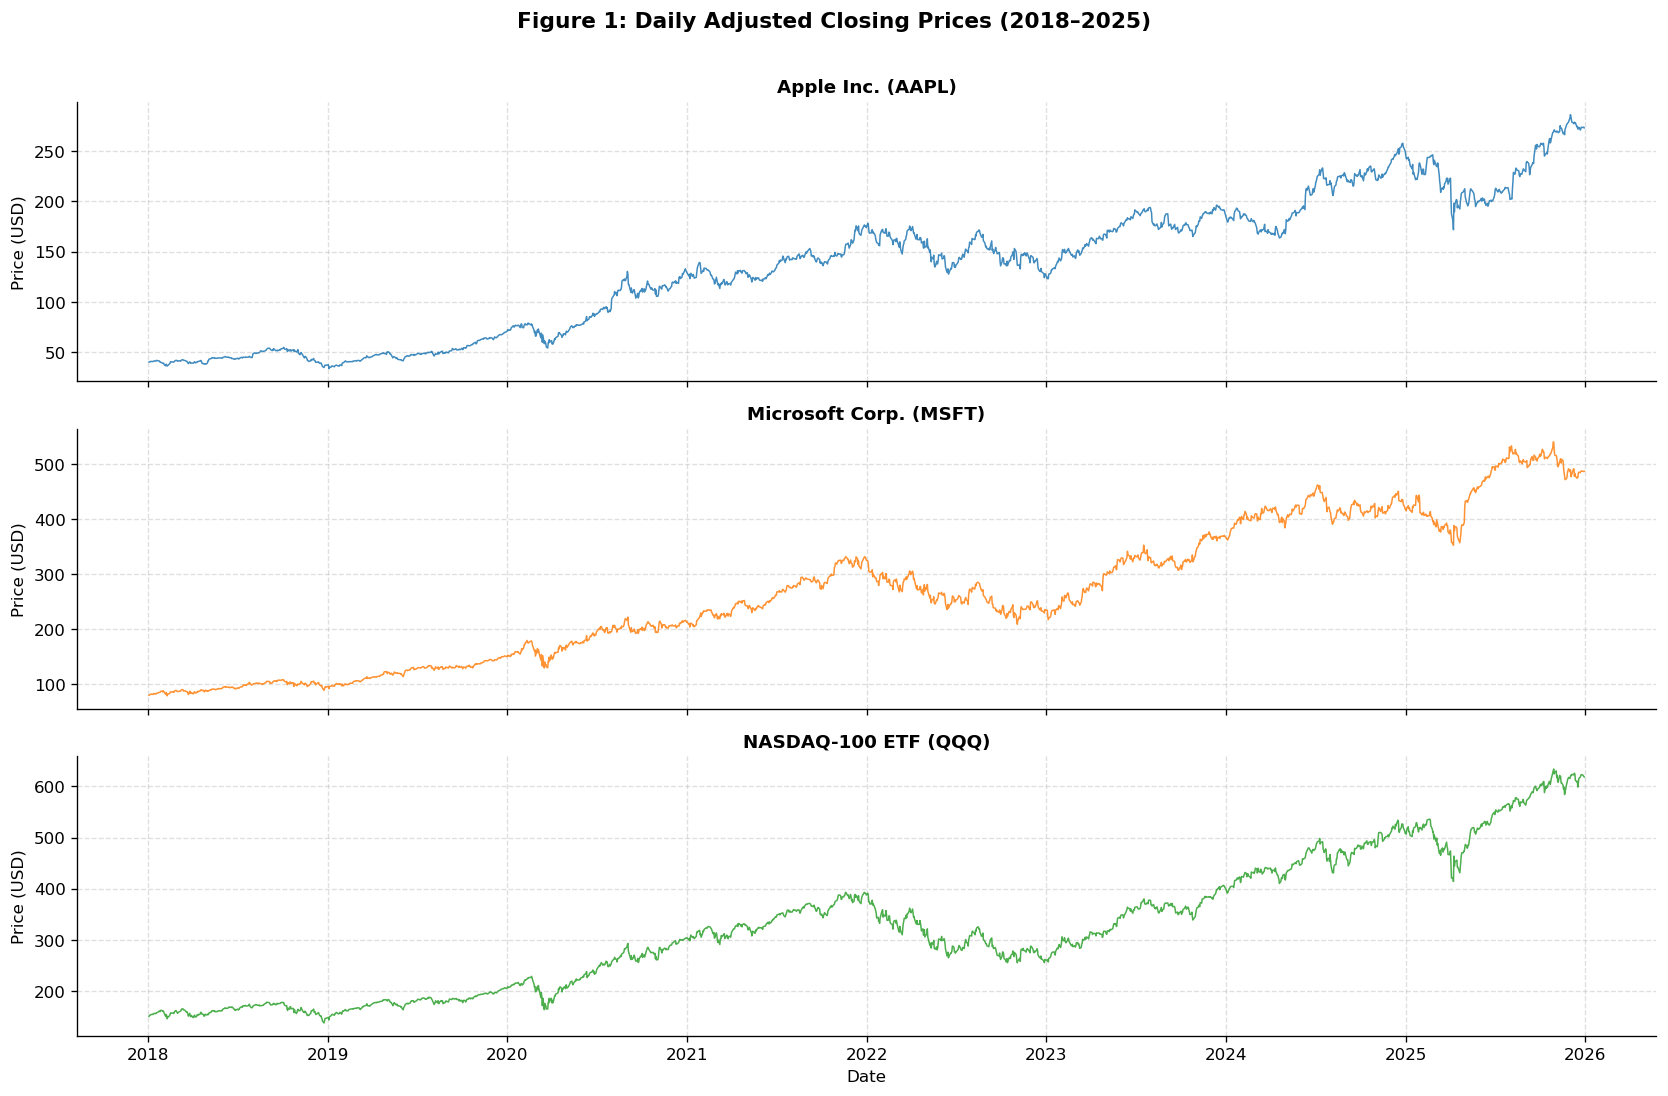

In [41]:
# ── Figure 1: Adjusted Closing Prices ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
titles = ['Apple Inc. (AAPL)', 'Microsoft Corp. (MSFT)', 'NASDAQ-100 ETF (QQQ)']

for ax, col, color, title in zip(axes, prices.columns, colors, titles):
    ax.plot(prices.index, prices[col], color=color, linewidth=0.9, alpha=0.85)
    ax.set_ylabel('Price (USD)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Date', fontsize=10)
fig.suptitle('Figure 1: Daily Adjusted Closing Prices (2018–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

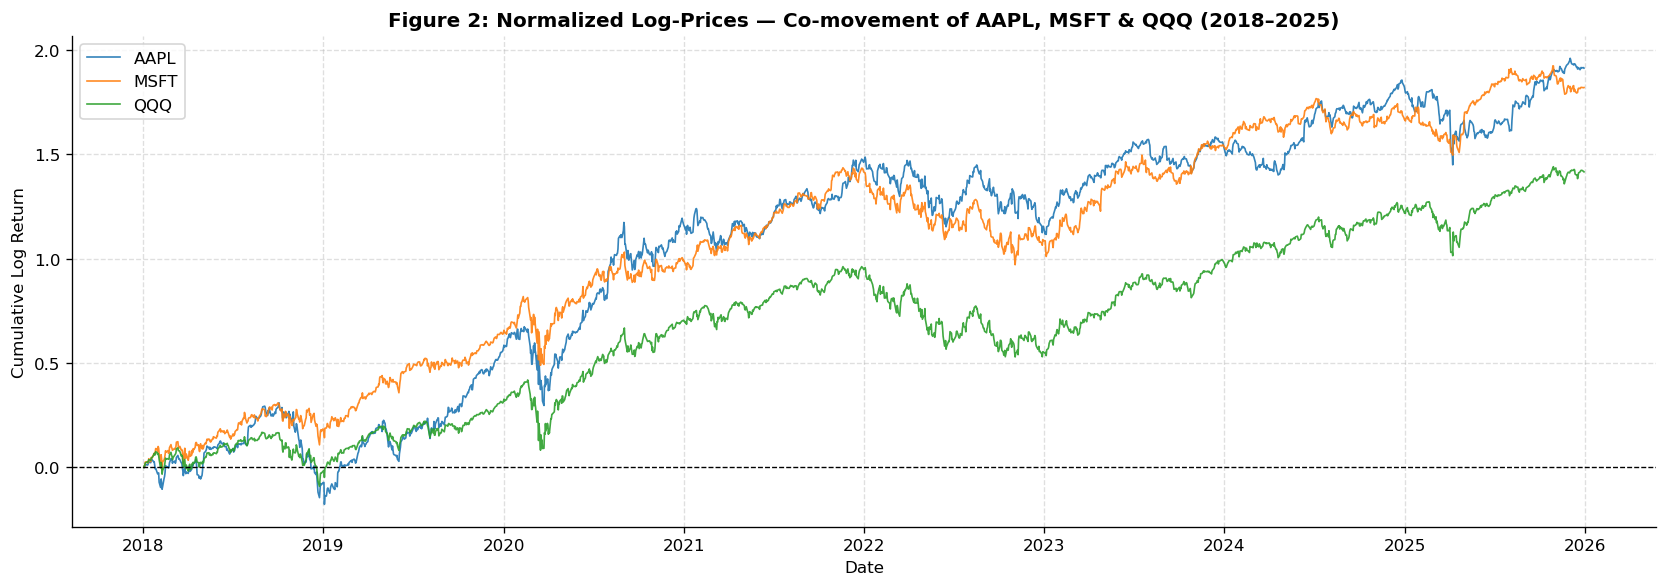

In [42]:
# ── Figure 2: Normalized Log-Prices (set to 0 at start) ─────────────────────
norm_log = log_prices - log_prices.iloc[0]

fig, ax = plt.subplots(figsize=(14, 5))
for col, color, label in zip(norm_log.columns, colors, ['AAPL', 'MSFT', 'QQQ']):
    ax.plot(norm_log.index, norm_log[col], color=color, linewidth=1.0, label=label, alpha=0.9)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_ylabel('Cumulative Log Return', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('Figure 2: Normalized Log-Prices — Co-movement of AAPL, MSFT & QQQ (2018–2025)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

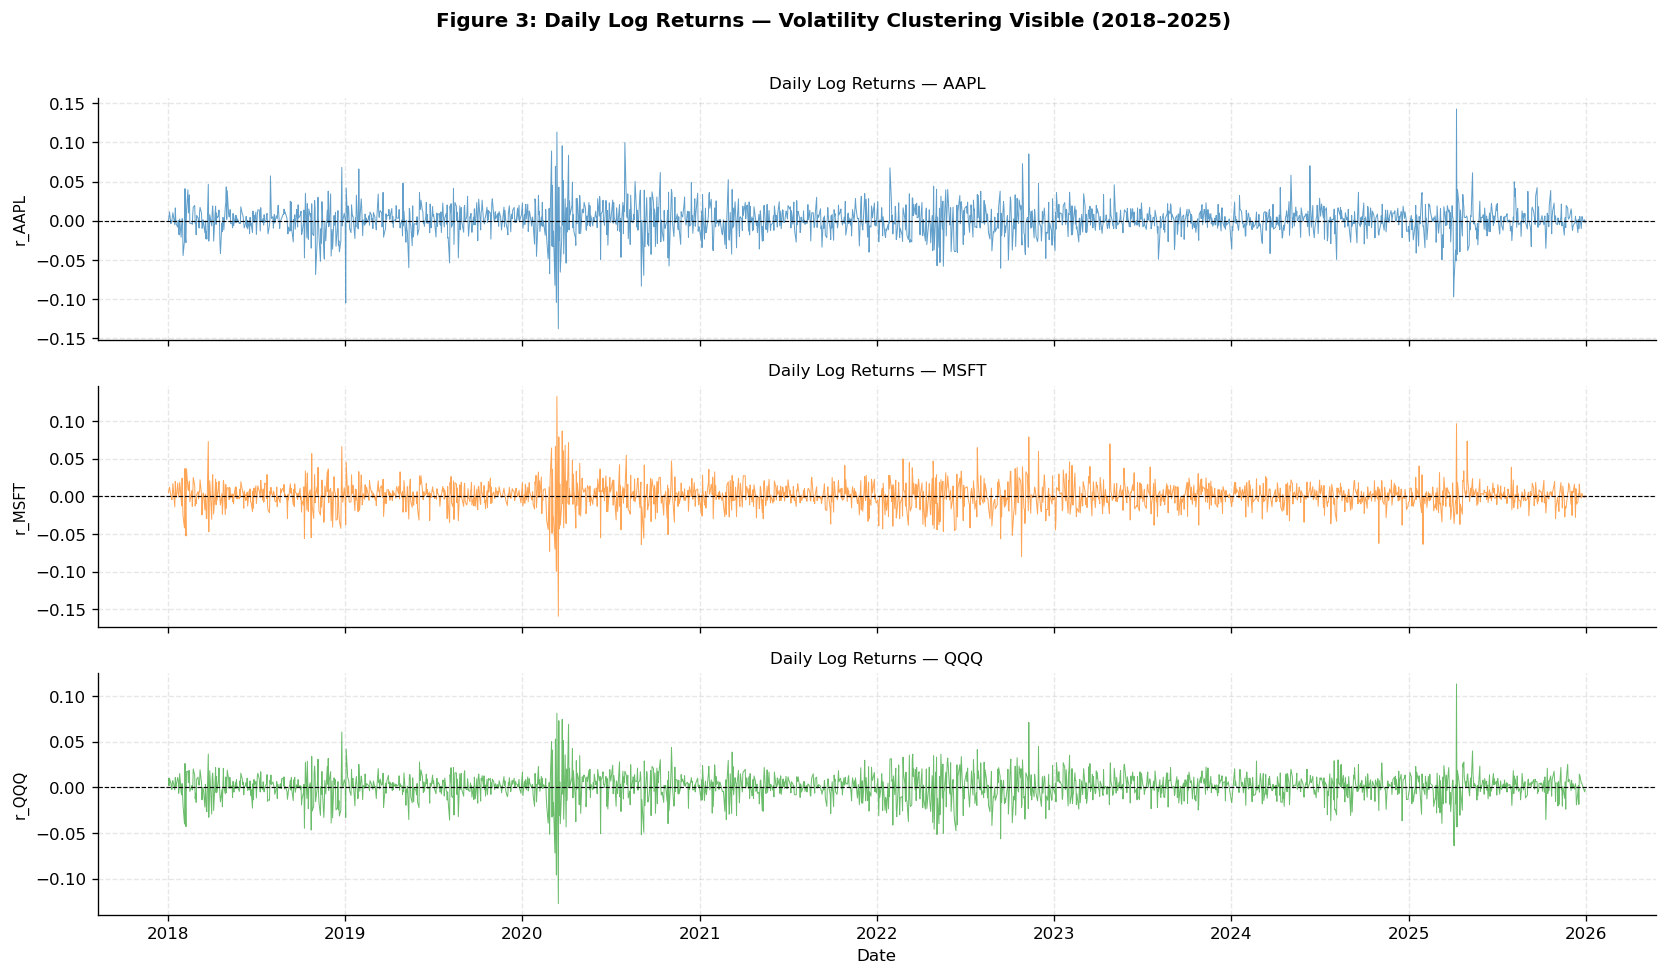

In [43]:
# ── Figure 3: Daily Log Returns ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, col, color, label in zip(axes, log_returns.columns, colors, ['AAPL', 'MSFT', 'QQQ']):
    ax.plot(log_returns.index, log_returns[col], color=color, linewidth=0.6, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_ylabel(f'r_{label}', fontsize=9)
    ax.set_title(f'Daily Log Returns — {label}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Figure 3: Daily Log Returns — Volatility Clustering Visible (2018–2025)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

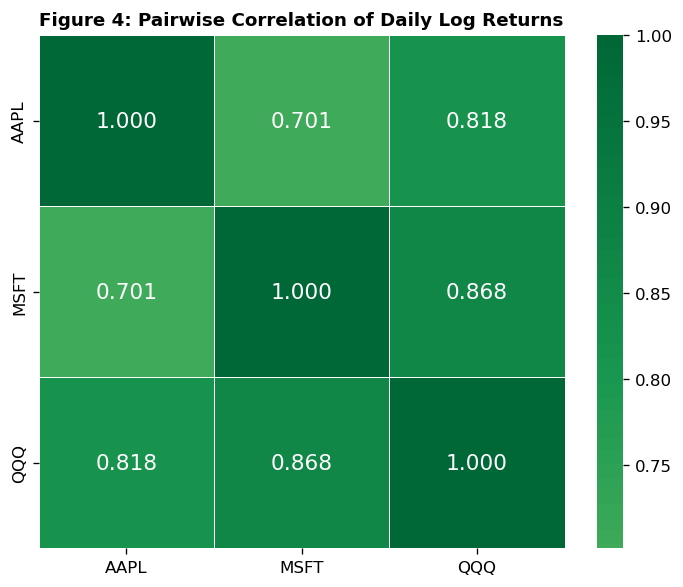

In [44]:
# ── Figure 4: Correlation Heatmap of Log Returns ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
corr = log_returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=False,
            xticklabels=['AAPL', 'MSFT', 'QQQ'],
            yticklabels=['AAPL', 'MSFT', 'QQQ'],
            annot_kws={'size': 13})
ax.set_title('Figure 4: Pairwise Correlation of Daily Log Returns', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Demonstration — Unit Root Tests (Establishing I(1))

In [45]:
def adf_test(series, name='', significance=0.05):
    """Augmented Dickey-Fuller test. H0: unit root (non-stationary)."""
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    decision = '✅ Stationary (reject H₀)' if pval < significance else '❌ Non-Stationary (fail to reject H₀)'
    print(f'  ADF  [{name:10s}]  Stat={stat:8.4f}  p={pval:.4f}  →  {decision}')
    return pval

def kpss_test(series, name='', significance=0.05):
    """KPSS test. H0: stationary."""
    result = kpss(series.dropna(), regression='c', nlags='auto')
    stat, pval = result[0], result[1]
    decision = '❌ Non-Stationary (reject H₀)' if pval < significance else '✅ Stationary (fail to reject H₀)'
    print(f'  KPSS [{name:10s}]  Stat={stat:8.4f}  p={pval:.4f}  →  {decision}')
    return pval

print('=' * 70)
print('UNIT ROOT TESTS ON LOG-PRICES (Levels — expected non-stationary)')
print('=' * 70)
for col in log_prices.columns:
    adf_test(log_prices[col], name=col)
    kpss_test(log_prices[col], name=col)
    print()

print('=' * 70)
print('UNIT ROOT TESTS ON LOG-RETURNS (First Differences — expected stationary)')
print('=' * 70)
for col in log_returns.columns:
    adf_test(log_returns[col], name=col)
    kpss_test(log_returns[col], name=col)
    print()

UNIT ROOT TESTS ON LOG-PRICES (Levels — expected non-stationary)
  ADF  [ln_AAPL   ]  Stat= -1.0292  p=0.7425  →  ❌ Non-Stationary (fail to reject H₀)
  KPSS [ln_AAPL   ]  Stat=  6.4196  p=0.0100  →  ❌ Non-Stationary (reject H₀)

  ADF  [ln_MSFT   ]  Stat= -1.4062  p=0.5793  →  ❌ Non-Stationary (fail to reject H₀)
  KPSS [ln_MSFT   ]  Stat=  6.5328  p=0.0100  →  ❌ Non-Stationary (reject H₀)

  ADF  [ln_QQQ    ]  Stat= -0.5017  p=0.8917  →  ❌ Non-Stationary (fail to reject H₀)
  KPSS [ln_QQQ    ]  Stat=  6.2893  p=0.0100  →  ❌ Non-Stationary (reject H₀)

UNIT ROOT TESTS ON LOG-RETURNS (First Differences — expected stationary)
  ADF  [r_AAPL    ]  Stat=-14.7011  p=0.0000  →  ✅ Stationary (reject H₀)
  KPSS [r_AAPL    ]  Stat=  0.0730  p=0.1000  →  ✅ Stationary (fail to reject H₀)

  ADF  [r_MSFT    ]  Stat=-14.9602  p=0.0000  →  ✅ Stationary (reject H₀)
  KPSS [r_MSFT    ]  Stat=  0.1101  p=0.1000  →  ✅ Stationary (fail to reject H₀)

  ADF  [r_QQQ     ]  Stat=-14.6076  p=0.0000  →  ✅ St

---
## 6. Demonstration — Johansen Cointegration Test

In [46]:
# ── Johansen Test ────────────────────────────────────────────────────────────
# det_order=0: constant in cointegrating vector (Case 2 of Johansen)
# k_ar_diff=5: 5 lags of differences in the VECM

data_matrix = log_prices.values  # shape (T, 3)

joh = coint_johansen(data_matrix, det_order=0, k_ar_diff=5)

print('\n' + '=' * 65)
print('JOHANSEN COINTEGRATION TEST  (det_order=0, k_ar_diff=5)')
print('=' * 65)

# Critical values at 90%, 95%, 99%
cv_trace = joh.cvt   # shape (n, 3)
cv_max   = joh.cvm   # shape (n, 3)
trace_stat = joh.lr1
max_stat   = joh.lr2
eig_vals   = joh.eig

print('\n── Trace Statistic ──')
print(f"{'H0: rank≤r':15s} {'Trace Stat':>12s} {'CV 90%':>10s} {'CV 95%':>10s} {'CV 99%':>10s} {'Reject H0 @5%':>15s}")
for r in range(len(trace_stat)):
    reject = '✅ Yes' if trace_stat[r] > cv_trace[r, 1] else '❌ No'
    print(f"  r ≤ {r}          {trace_stat[r]:12.4f} {cv_trace[r,0]:10.4f} {cv_trace[r,1]:10.4f} {cv_trace[r,2]:10.4f} {reject:>15s}")

print('\n── Max-Eigenvalue Statistic ──')
print(f"{'H0: rank=r':15s} {'Max-Eig Stat':>12s} {'CV 90%':>10s} {'CV 95%':>10s} {'CV 99%':>10s} {'Reject H0 @5%':>15s}")
for r in range(len(max_stat)):
    reject = '✅ Yes' if max_stat[r] > cv_max[r, 1] else '❌ No'
    print(f"  r = {r}          {max_stat[r]:12.4f} {cv_max[r,0]:10.4f} {cv_max[r,1]:10.4f} {cv_max[r,2]:10.4f} {reject:>15s}")

print('\n── Eigenvalues ──')
for i, ev in enumerate(eig_vals):
    print(f'  λ_{i+1} = {ev:.6f}')

print('\n── Cointegrating Vectors (β) ──')
beta = pd.DataFrame(joh.evec, index=['ln_AAPL', 'ln_MSFT', 'ln_QQQ'],
                    columns=[f'CV_{i+1}' for i in range(joh.evec.shape[1])])
print(beta.round(6))


JOHANSEN COINTEGRATION TEST  (det_order=0, k_ar_diff=5)

── Trace Statistic ──
H0: rank≤r        Trace Stat     CV 90%     CV 95%     CV 99%   Reject H0 @5%
  r ≤ 0               19.5261    27.0669    29.7961    35.4628            ❌ No
  r ≤ 1                6.6922    13.4294    15.4943    19.9349            ❌ No
  r ≤ 2                1.0715     2.7055     3.8415     6.6349            ❌ No

── Max-Eigenvalue Statistic ──
H0: rank=r      Max-Eig Stat     CV 90%     CV 95%     CV 99%   Reject H0 @5%
  r = 0               12.8339    18.8928    21.1314    25.8650            ❌ No
  r = 1                5.6207    12.2971    14.2639    18.5200            ❌ No
  r = 2                1.0715     2.7055     3.8415     6.6349            ❌ No

── Eigenvalues ──
  λ_1 = 0.006384
  λ_2 = 0.002801
  λ_3 = 0.000535

── Cointegrating Vectors (β) ──
            CV_1    CV_2    CV_3
ln_AAPL   6.7030 -3.4519 -3.0680
ln_MSFT -12.2501 -0.1620 -4.9361
ln_QQQ    5.7805  3.0552 11.9836


---
## 7. Demonstration — VECM Estimation

In [47]:
# ── Fit VECM ─────────────────────────────────────────────────────────────────
# Based on Johansen test result: assume rank r=1
# k_ar_lags=5 (lags in the VAR representation → k_ar_diff = k_ar_lags - 1 = 4)

model = VECM(log_prices, k_ar_diff=4, coint_rank=1, deterministic='ci')
vecm_result = model.fit()

print(vecm_result.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ln_AAPL
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.ln_AAPL     0.0176      0.039      0.458      0.647      -0.058       0.093
L1.ln_MSFT    -0.0897      0.049     -1.841      0.066      -0.185       0.006
L1.ln_QQQ     -0.0437      0.071     -0.619      0.536      -0.182       0.095
L2.ln_AAPL    -0.0517      0.039     -1.339      0.181      -0.127       0.024
L2.ln_MSFT    -0.1774      0.049     -3.630      0.000      -0.273      -0.082
L2.ln_QQQ      0.2723      0.071      3.858      0.000       0.134       0.411
L3.ln_AAPL    -0.0531      0.039     -1.376      0.169      -0.129       0.023
L3.ln_MSFT     0.0971      0.049      1.983      0.047       0.001       0.193
L3.ln_QQQ     -0.0581      0.071     -0.821      0.411      -0.197       0.081
L4.ln_AAPL    -0.0365      0.039     -0.946 

In [48]:
# ── Parameter Interpretation ─────────────────────────────────────────────────
alpha = vecm_result.alpha          # Adjustment (loading) coefficients
beta_hat = vecm_result.beta        # Cointegrating vector

print('=' * 60)
print('VECM PARAMETER INTERPRETATION')
print('=' * 60)

print('\n1. Cointegrating Vector (β) — Long-Run Equilibrium:')
print('   Interpretation: The equilibrium relationship is defined by')
print('   the weighted log-price combination that is I(0).\n')
beta_df = pd.DataFrame(beta_hat, index=log_prices.columns, columns=['β (CV1)'])
print(beta_df.round(6))

print('\n2. Adjustment (Loading) Coefficients (α):')
print('   Interpretation: How fast each series corrects toward equilibrium.')
print('   Negative α → series corrects toward equilibrium when above it.\n')
alpha_df = pd.DataFrame(alpha, index=log_prices.columns, columns=['α (CV1)'])
print(alpha_df.round(6))
for i, ticker in enumerate(log_prices.columns):
    a = alpha[i, 0]
    direction = 'corrects ↓ when above equilibrium' if a < 0 else 'corrects ↑ when below equilibrium'
    half_life = abs(np.log(0.5) / np.log(1 + a)) if abs(a) < 1 else np.nan
    print(f'   {ticker}: α = {a:.6f} → {direction}; approx. half-life ≈ {half_life:.1f} trading days')

VECM PARAMETER INTERPRETATION

1. Cointegrating Vector (β) — Long-Run Equilibrium:
   Interpretation: The equilibrium relationship is defined by
   the weighted log-price combination that is I(0).

         β (CV1)
ln_AAPL   1.0000
ln_MSFT  -1.5710
ln_QQQ    0.6788

2. Adjustment (Loading) Coefficients (α):
   Interpretation: How fast each series corrects toward equilibrium.
   Negative α → series corrects toward equilibrium when above it.

         α (CV1)
ln_AAPL  -0.0097
ln_MSFT  -0.0064
ln_QQQ   -0.0065
   ln_AAPL: α = -0.009712 → corrects ↓ when above equilibrium; approx. half-life ≈ 71.0 trading days
   ln_MSFT: α = -0.006442 → corrects ↓ when above equilibrium; approx. half-life ≈ 107.2 trading days
   ln_QQQ: α = -0.006494 → corrects ↓ when above equilibrium; approx. half-life ≈ 106.4 trading days


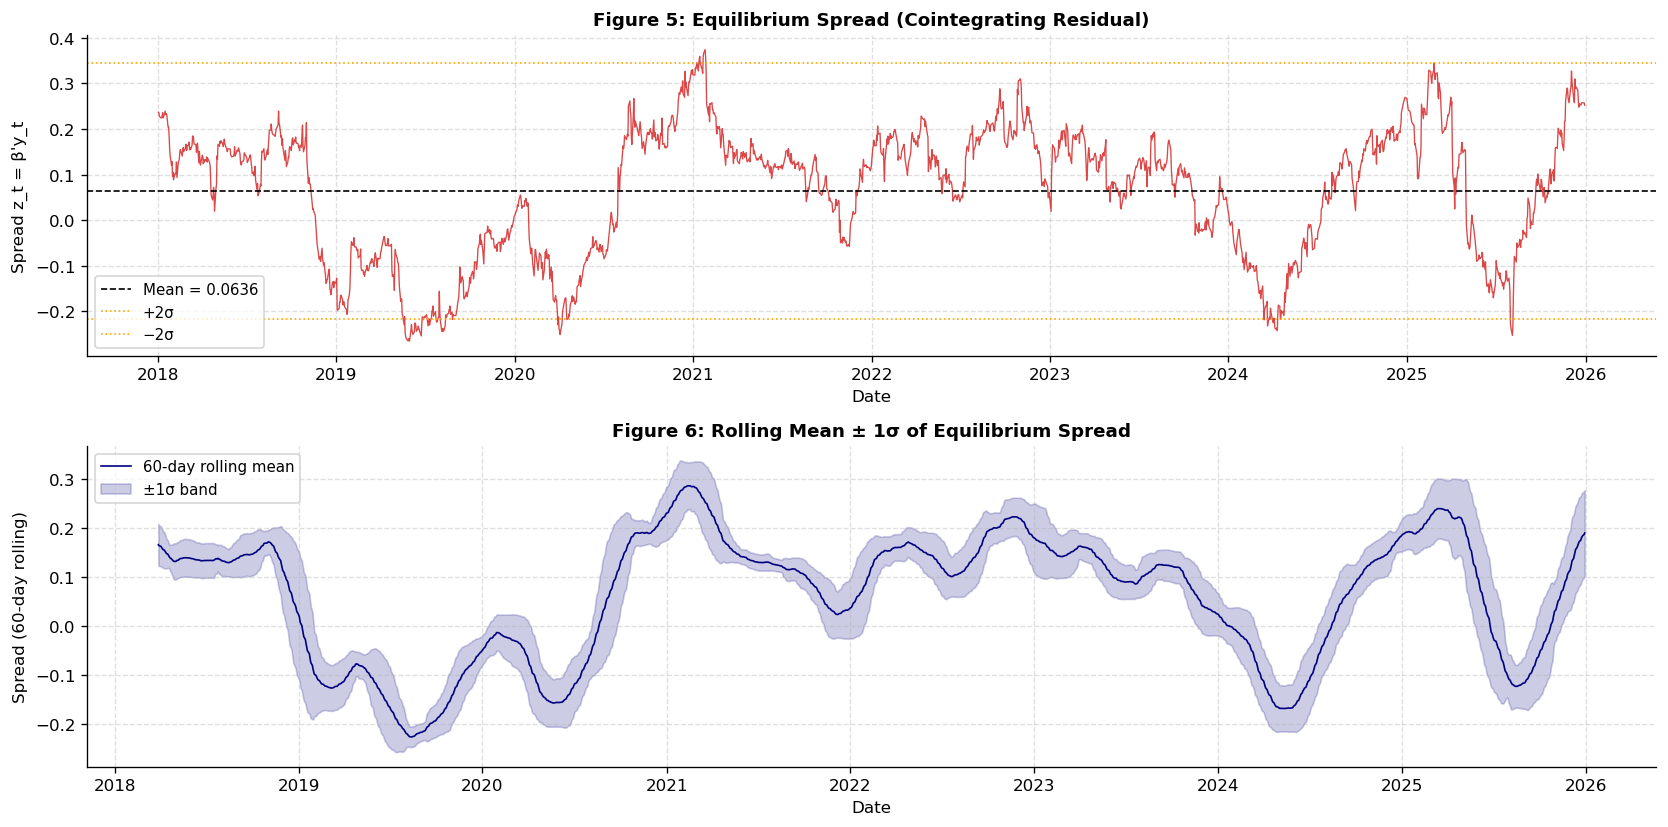

In [49]:
# ── Compute and Plot Equilibrium Spread ──────────────────────────────────────
spread = log_prices.values @ beta_hat[:, 0]   # z_t = β'y_t
spread_series = pd.Series(spread, index=log_prices.index, name='Equilibrium Spread')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot spread
axes[0].plot(spread_series.index, spread_series, color='#d62728', linewidth=0.8, alpha=0.85)
mean_spread = spread_series.mean()
std_spread  = spread_series.std()
axes[0].axhline(mean_spread, color='black', linestyle='--', linewidth=1.0, label=f'Mean = {mean_spread:.4f}')
axes[0].axhline(mean_spread + 2*std_spread, color='orange', linestyle=':', linewidth=1.0, label='+2σ')
axes[0].axhline(mean_spread - 2*std_spread, color='orange', linestyle=':', linewidth=1.0, label='−2σ')
axes[0].set_ylabel("Spread z_t = β'y_t", fontsize=10)
axes[0].set_title('Figure 5: Equilibrium Spread (Cointegrating Residual)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Rolling mean and std of spread
roll = spread_series.rolling(window=60)
axes[1].plot(roll.mean(), color='navy', linewidth=1.0, label='60-day rolling mean')
axes[1].fill_between(spread_series.index,
                     roll.mean() - roll.std(),
                     roll.mean() + roll.std(),
                     alpha=0.2, color='navy', label='±1σ band')
axes[1].set_ylabel('Spread (60-day rolling)', fontsize=10)
axes[1].set_title('Figure 6: Rolling Mean ± 1σ of Equilibrium Spread', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.4)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlabel('Date', fontsize=10)

plt.tight_layout()
plt.show()

---
## 8. Diagnosis — Residual Diagnostics

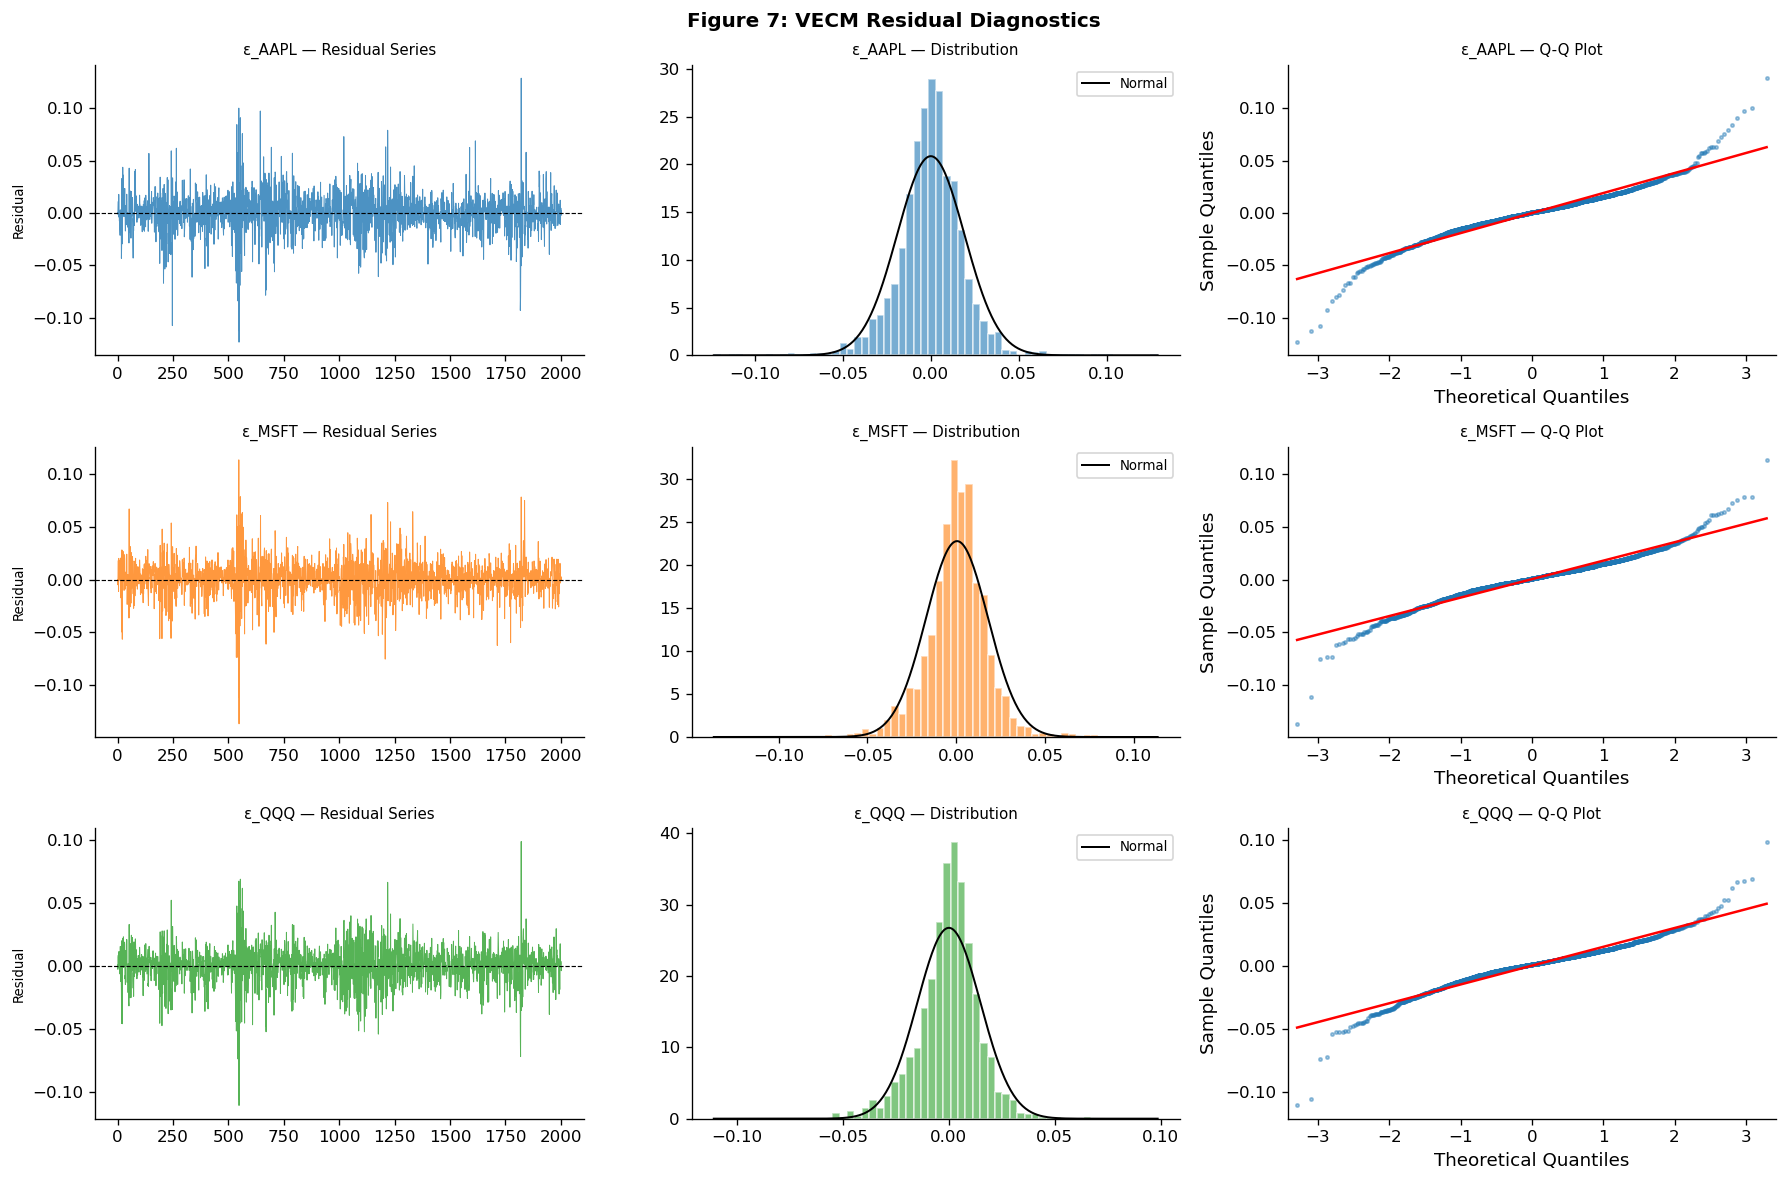

In [50]:
# ── Extract VECM Residuals ────────────────────────────────────────────────────
resid = vecm_result.resid   # shape (T - k_ar_diff - 1, 3)
resid_df = pd.DataFrame(resid, columns=['ε_AAPL', 'ε_MSFT', 'ε_QQQ'])

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
resid_labels = ['ε_AAPL', 'ε_MSFT', 'ε_QQQ']

for i, col in enumerate(resid_df.columns):
    r = resid_df[col].values

    # Time plot
    axes[i, 0].plot(r, color=colors[i], linewidth=0.6, alpha=0.8)
    axes[i, 0].axhline(0, color='black', linewidth=0.7, linestyle='--')
    axes[i, 0].set_title(f'{col} — Residual Series', fontsize=9)
    axes[i, 0].set_ylabel('Residual', fontsize=8)

    # Histogram + KDE
    axes[i, 1].hist(r, bins=60, color=colors[i], alpha=0.6, density=True, edgecolor='white')
    xr = np.linspace(r.min(), r.max(), 300)
    axes[i, 1].plot(xr, stats.norm.pdf(xr, r.mean(), r.std()), 'k-', linewidth=1.2, label='Normal')
    axes[i, 1].set_title(f'{col} — Distribution', fontsize=9)
    axes[i, 1].legend(fontsize=8)

    # Q-Q plot
    sm.qqplot(r, line='s', ax=axes[i, 2], alpha=0.4, markersize=2)
    axes[i, 2].set_title(f'{col} — Q-Q Plot', fontsize=9)

fig.suptitle('Figure 7: VECM Residual Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

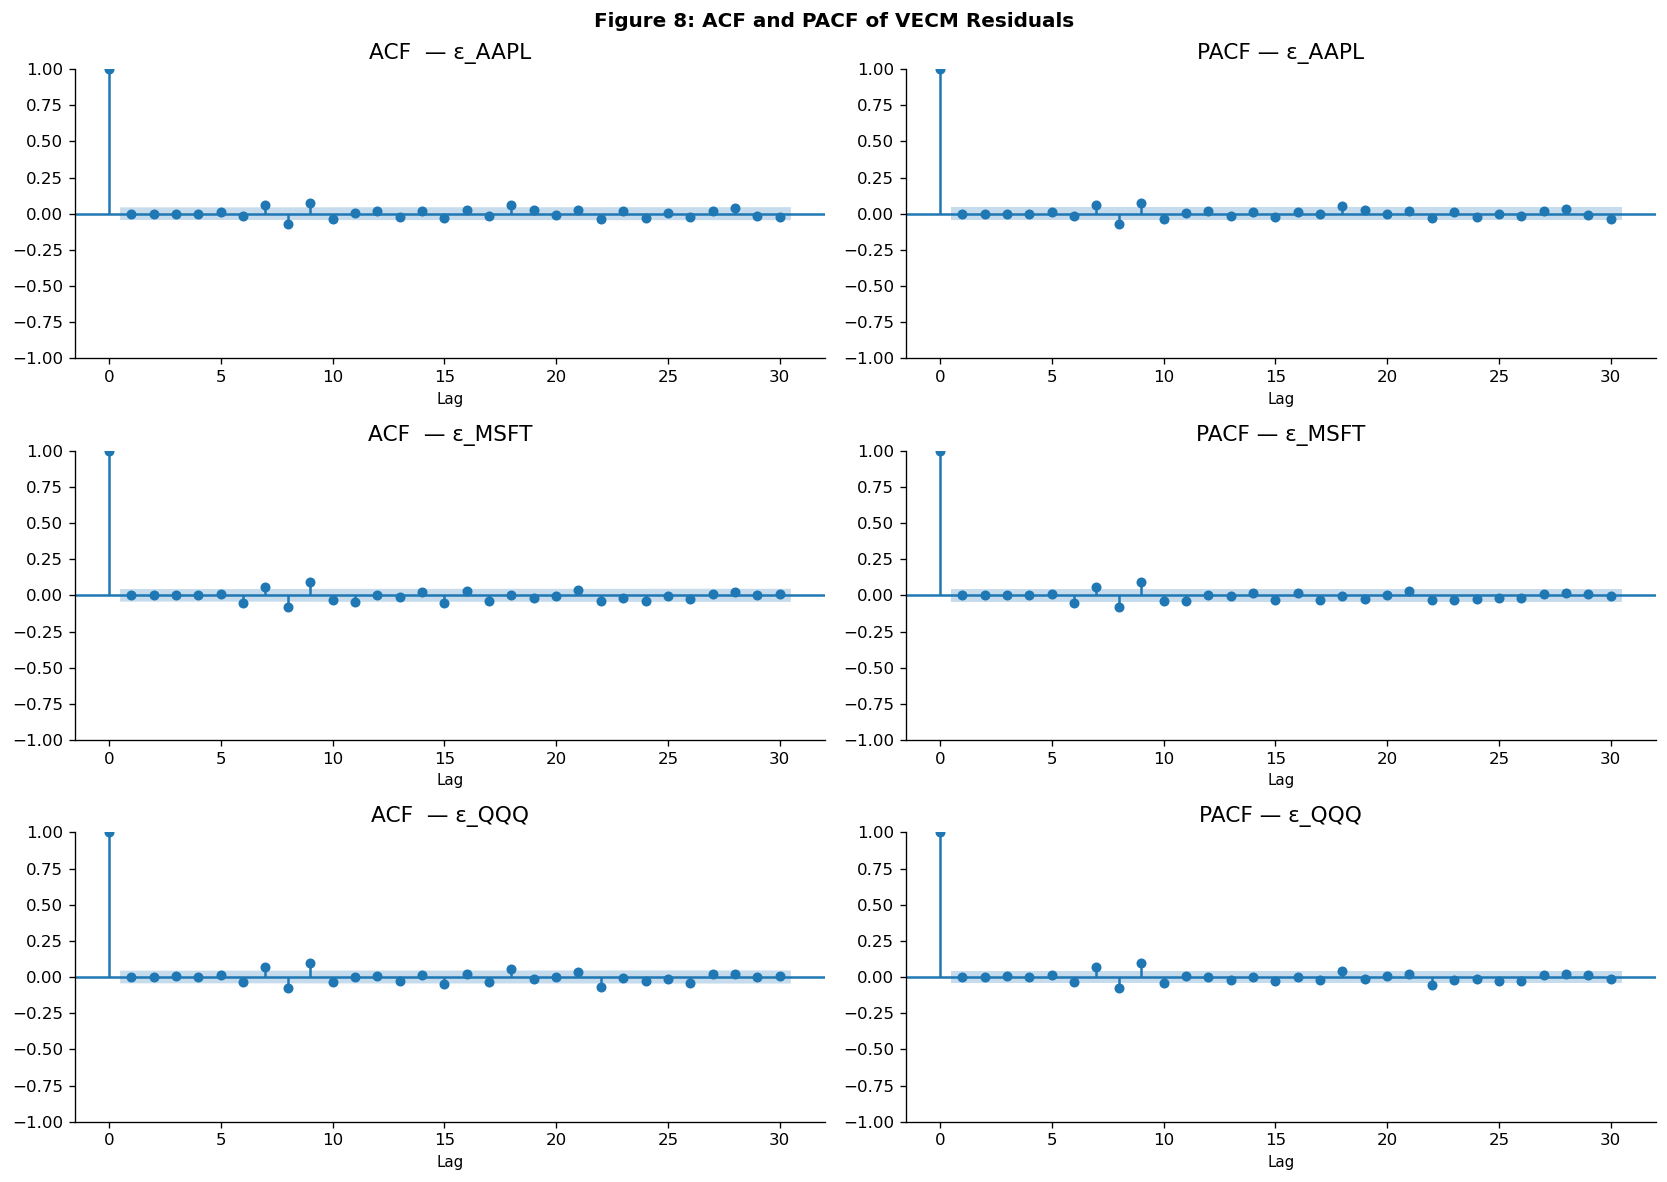

In [51]:
# ── ACF / PACF of Residuals ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(resid_df.columns):
    r = resid_df[col].dropna()
    plot_acf(r,  lags=30, ax=axes[i, 0], title=f'ACF  — {col}',  alpha=0.05)
    plot_pacf(r, lags=30, ax=axes[i, 1], title=f'PACF — {col}', alpha=0.05, method='ywm')
    for ax in axes[i]:
        ax.set_xlabel('Lag', fontsize=9)

fig.suptitle('Figure 8: ACF and PACF of VECM Residuals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# ── Statistical Diagnostics Table ────────────────────────────────────────────
print('=' * 75)
print('RESIDUAL DIAGNOSTIC TESTS')
print('=' * 75)

for col in resid_df.columns:
    r = resid_df[col].dropna().values
    print(f'\n── {col} ──')

    # Normality
    jb_stat, jb_p = stats.jarque_bera(r)
    sw_stat, sw_p = stats.shapiro(r[:5000] if len(r) > 5000 else r)

    # Autocorrelation (Ljung-Box proxy via ADF on residuals)
    dw = durbin_watson(r)

    # ARCH effects
    arch_stat, arch_p, _, _ = het_arch(r)

    # Unit root in residuals (should be stationary)
    adf_stat, adf_p, *_ = adfuller(r, autolag='AIC')

    print(f'  Jarque-Bera    : stat={jb_stat:.4f}, p={jb_p:.6f}  → {"Non-normal" if jb_p<0.05 else "Normal"}')
    print(f'  Shapiro-Wilk   : stat={sw_stat:.4f}, p={sw_p:.6f}  → {"Non-normal" if sw_p<0.05 else "Normal"}')
    print(f'  Durbin-Watson  : {dw:.4f}  → {"No autocorrelation" if 1.5<dw<2.5 else "⚠ Possible autocorrelation"}')
    print(f'  ARCH LM Test   : stat={arch_stat:.4f}, p={arch_p:.6f}  → {"ARCH effects present" if arch_p<0.05 else "No ARCH effects"}')
    print(f'  ADF (residuals): stat={adf_stat:.4f}, p={adf_p:.6f}  → {"Stationary ✅" if adf_p<0.05 else "Non-stationary ❌"}')

RESIDUAL DIAGNOSTIC TESTS

── ε_AAPL ──
  Jarque-Bera    : stat=2290.7747, p=0.000000  → Non-normal
  Shapiro-Wilk   : stat=0.9441, p=0.000000  → Non-normal
  Durbin-Watson  : 1.9996  → No autocorrelation
  ARCH LM Test   : stat=264.0237, p=0.000000  → ARCH effects present
  ADF (residuals): stat=-13.9616, p=0.000000  → Stationary ✅

── ε_MSFT ──
  Jarque-Bera    : stat=2305.6670, p=0.000000  → Non-normal
  Shapiro-Wilk   : stat=0.9490, p=0.000000  → Non-normal
  Durbin-Watson  : 1.9990  → No autocorrelation
  ARCH LM Test   : stat=462.6833, p=0.000000  → ARCH effects present
  ADF (residuals): stat=-14.0079, p=0.000000  → Stationary ✅

── ε_QQQ ──
  Jarque-Bera    : stat=2508.3491, p=0.000000  → Non-normal
  Shapiro-Wilk   : stat=0.9449, p=0.000000  → Non-normal
  Durbin-Watson  : 1.9986  → No autocorrelation
  ARCH LM Test   : stat=389.8280, p=0.000000  → ARCH effects present
  ADF (residuals): stat=-13.7899, p=0.000000  → Stationary ✅


---
## 9. Damage — Identified Problems

Based on the diagnostics above, the following challenges may affect model quality:

| Challenge | Description | Evidence |
|-----------|-------------|----------|
| **Fat tails / Non-normality** | Residuals exhibit excess kurtosis and skewness | Jarque-Bera rejection; Q-Q tail deviations |
| **Volatility Clustering (ARCH)** | Variance is not constant over time | ARCH LM test rejection; visible in return plots |
| **Structural Breaks** | COVID-19 crash (Mar 2020), rate hike cycle (2022), AI surge (2023) | Visual inspection; rolling mean of spread shifts |
| **Parameter Instability** | β and α may not be stable across full 7-year window | Rolling cointegration test recommended |
| **Lag Selection Uncertainty** | AIC/BIC may disagree on optimal lag length | Compare multiple lag specifications |
| **Omitted Variables** | Three-variable system may miss macro drivers (Fed funds rate, VIX) | Low R² in short-run equations |

  NON TECHNICAL PART                                                  ### Clear Explanation of Results

Our analysis looked at how Apple (AAPL), Microsoft (MSFT), and the NASDAQ-100 (QQQ) move together. We've assessed how well our understanding captures their behaviors, focusing on the unpredictable parts of their price movements (what our current approach can't fully explain).

Here’s what we found for each of these assets:

*   **Unusual Price Swings:** For AAPL, MSFT, and QQQ, we observed that price changes aren't always evenly distributed. This means that extreme ups and downs happen more often than a simple, predictable pattern would suggest.
    *   **Investment Implication:** This tells us that standard risk models, which often assume more regular price movements, might underestimate the likelihood of very large gains or losses. It's a reminder that market shocks can be more severe than expected.

*   **Independent Movements:** We found that today's unexplained price movements generally don't predict tomorrow's. This is good news, as it means our current approach has largely captured the main trends and immediate influences on these assets.

*   **Clustering Volatility:** A key finding is that periods of high market turbulence (like big price swings) tend to stick together. If the market is volatile today, it's more likely to be volatile tomorrow. The same goes for calm periods.
    *   **Investment Implication:** This is crucial for risk management. It means that the level of risk isn't constant; it changes. During turbulent times, our risk exposure is higher and more persistent. Any investment strategy needs to adapt to these changing levels of market risk.

*   **Long-Term Connection Holds:** Despite individual stock prices moving around, we confirmed that AAPL, MSFT, and QQQ maintain a stable, long-term relationship. When one temporarily moves too far out of sync with the others, it tends to come back into line.
    *   **Investment Implication:** This confirms the basis for strategies that aim to profit from these assets returning to their natural alignment, like "pairs trading" or "triplet trading," where you buy the underperforming asset and sell the outperforming one, expecting them to converge.

### Recommended Course of Action

To make our investment strategies more reliable and to better predict how these assets might move, here are the recommended next steps:

1.  **Account for Changing Market Risk:** Since market volatility tends to cluster, we need to use tools that specifically forecast these changing risk levels. This will give us a more accurate picture of potential future price swings and help us manage risk more effectively.
    *   **Investment Implication:** This allows for dynamic position sizing, where we reduce exposure during expected high volatility and increase it during calmer periods, optimizing risk-adjusted returns.

2.  **Adapt to Different Market Phases:** Major events like economic crises or significant policy changes can alter how assets behave. We should analyze these assets separately during different market phases (e.g., pre-COVID, post-COVID, periods of rising interest rates) to ensure our strategies are based on the most relevant relationships for the current environment.
    *   **Investment Implication:** This ensures that our strategies are not based on outdated market dynamics, leading to more robust decision-making across varied economic conditions.

3.  **Consider Broader Market Influences:** Our current analysis focuses only on AAPL, MSFT, and QQQ. However, external factors like interest rates, overall market fear (e.g., VIX), or general economic sentiment can significantly influence these assets. Including these broader market signals could improve our predictions and reveal hidden drivers of performance.
    *   **Investment Implication:** By understanding these external factors, we can build more comprehensive strategies that react to the bigger picture, not just the individual asset movements.

4.  **Refine Short-Term Forecasting:** The current model considers past asset movements to predict future ones. We should carefully review how many past days are most relevant for these short-term predictions to ensure we capture dynamic interactions accurately without overreacting to noise.
    *   **Investment Implication:** Optimal short-term predictions improve the timing of trades and the effectiveness of mean-reversion strategies.

5.  **Understand Asymmetric Reactions:** Sometimes, assets might return to equilibrium faster when they're significantly overvalued than when they're undervalued, or vice-versa. Investigating if such asymmetric behavior exists can help us refine our entry and exit points for trades.
    *   **Investment Implication:** This can lead to more precise and profitable trading signals, especially for mean-reversion strategies, by adapting to how assets behave under different stress levels.

6.  **Manage Extreme Events:** Financial markets experience rare but extreme events (e.g., flash crashes). While these are part of market reality, understanding their impact on our model is important. We should consider techniques to reduce the disproportionate influence of these outliers on our overall strategy without ignoring the lessons they provide.
    *   **Investment Implication:** This helps create more resilient strategies that aren't overly distorted by one-off events, maintaining consistency in performance.

### Identification of Factors Impacting Each Portfolio

When building a portfolio with Apple (AAPL), Microsoft (MSFT), and the NASDAQ-100 (QQQ), several key factors influence each asset and the overall portfolio performance:

*   **Long-Term Connection:** Even though the prices of AAPL, MSFT, and QQQ move up and down in their own ways, they share a fundamental long-term connection. This means that while they might drift apart temporarily, they tend to come back into a predictable alignment over time.
    *   **Investment Implication:** This underlying connection is the basis for strategies that bet on a return to normal, where you can profit by taking opposite positions on assets that have temporarily deviated too far from this shared path.

*   **How Quickly Each Asset Adjusts:** Each asset reacts differently when it strays from the group's long-term connection.
    *   **AAPL:** Tends to adjust back to the group's trend relatively quickly, typically within about 71 trading days.
    *   **MSFT & QQQ:** Adjust more slowly, often taking around 106-107 trading days to realign with the group.
    *   **Investment Implication:** Knowing these different adjustment speeds is crucial for designing trading strategies. For instance, a faster adjusting asset might offer more frequent opportunities for quick profits when deviations occur, while slower ones might require more patience.

*   **Major Market Events:** Significant events like the COVID-19 pandemic, changes in interest rates, or breakthroughs in technology (e.g., the surge in AI) can drastically change how these assets relate to each other. These events can make their long-term connections unstable for a period. Our analysis shows that this stable connection isn't always present; it's detected only about 7.6% of the time over rolling two-year periods.
    *   **Investment Implication:** This means investment strategies based on these connections need to be flexible and regularly reviewed. What worked in one market environment might not work in another, emphasizing the need for adaptable strategies.

*   **Changing Risk Levels:** The risk associated with these assets isn't constant. Periods of high market volatility in one asset tend to be followed by more high volatility.
    *   **Investment Implication:** This dynamic nature of risk means that investors need to continuously monitor and adjust their risk exposure, rather than assuming a fixed level of risk. This impacts how options are priced and how overall portfolio risk is managed.

*   **Hidden Influences:** Our current view is focused on just these three assets. However, many other external factors—like broader economic indicators, general market sentiment, or specific company news—can influence their performance. Not fully accounting for these could mean we're missing crucial drivers of their price movements.
    *   **Investment Implication:** A more holistic view that incorporates these broader economic and market signals could lead to more robust and less surprising investment outcomes.

These factors together paint a picture of a dynamic market where understanding long-term relationships, individual asset behaviors, and external influences is key to making informed investment decisions.

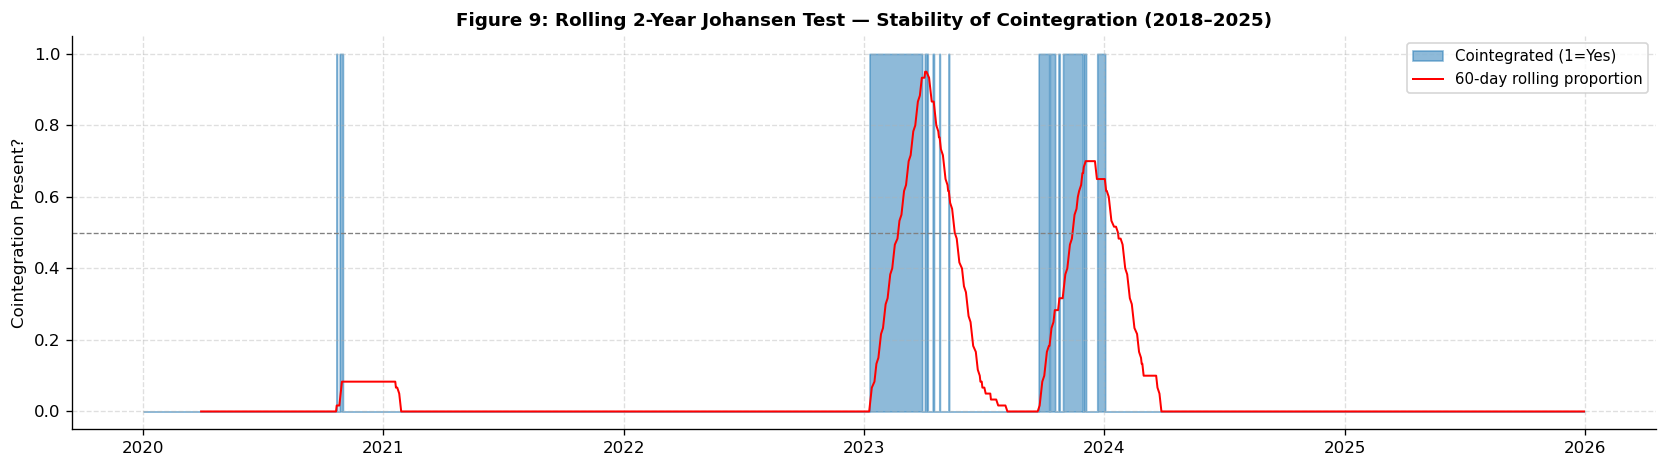

Cointegration detected in 7.6% of rolling windows.


In [53]:
# ── Rolling Cointegration (Structural Stability Check) ───────────────────────
window = 504   # ~2 trading years
roll_pvals = []

for end in range(window, len(log_prices)):
    sub = log_prices.iloc[end - window: end]
    try:
        j = coint_johansen(sub.values, det_order=0, k_ar_diff=2)
        # Use trace statistic vs 95% CV for rank=0 test
        is_coint = int(j.lr1[0] > j.cvt[0, 1])
    except Exception:
        is_coint = np.nan
    roll_pvals.append(is_coint)

roll_idx = log_prices.index[window:]
roll_series = pd.Series(roll_pvals, index=roll_idx)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(roll_idx, 0, roll_series, step='mid', alpha=0.5, color='#1f77b4', label='Cointegrated (1=Yes)')
ax.plot(roll_idx, roll_series.rolling(60).mean(), color='red', linewidth=1.2, label='60-day rolling proportion')
ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8)
ax.set_ylabel('Cointegration Present?', fontsize=10)
ax.set_title('Figure 9: Rolling 2-Year Johansen Test — Stability of Cointegration (2018–2025)',
             fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

pct = roll_series.mean() * 100
print(f'Cointegration detected in {pct:.1f}% of rolling windows.')

---
## 10. Directions — Model Improvement Strategies

Given the identified problems, the following refinements are recommended:

1. **VECM-GARCH**: Combine the VECM with a multivariate GARCH (DCC-GARCH or BEKK-GARCH) to handle time-varying volatility. This directly addresses the ARCH effects in residuals.

2. **Sub-period analysis**: Split the sample at structural break dates (e.g., pre/post-COVID; pre/post-2022 Fed tightening) and estimate VECM separately. This handles parameter instability.

3. **Expand the variable set**: Include the 10-year Treasury yield, VIX, and sector ETFs to reduce omitted variable bias in the short-run equations.

4. **Robust lag selection**: Apply information criteria (AIC, BIC, HQIC) jointly and compare impulse response functions across lag specifications.

5. **Threshold VECM (TVECM)**: Allow adjustment speeds ($\alpha$) to differ depending on whether the spread is above or below a threshold. This captures asymmetric adjustment documented in equity pairs.

6. **Outlier trimming**: Remove extreme return dates (e.g., March 2020, ±5σ events) and re-estimate to assess robustness.

---
## 11. Deployment — Practical Application of the VECM

### 11.1 Statistical Arbitrage (Pairs / Triplet Trading)
The equilibrium spread $z_t = \boldsymbol{\beta}'\mathbf{y}_t$ is stationary with a known mean and variance. A practical trading strategy:
- **Entry**: Open a long-short position (long the underperformer, short the outperformer) when $|z_t - \bar{z}| > 2\sigma_z$.
- **Exit**: Close the position when $z_t$ reverts to within $0.5\sigma_z$ of the mean.
- **Risk Management**: Adjust position sizes using the estimated half-life of mean reversion derived from $\alpha$.

### 11.2 Risk Monitoring Dashboard
A real-time dashboard consuming daily closing prices can compute $z_t$ continuously and flag when equilibrium divergence exceeds historical thresholds. This is useful for portfolio risk officers tracking sector exposure.

### 11.3 Impulse Response & Forecasting
The VECM can generate conditional forecasts: given today's log-prices and the estimated parameters, forecast next $h$-day log-prices while respecting the long-run cointegrating constraint. These can be used to set option strike targets or hedge ratios.

### 11.4 Implementation Considerations
- **Re-estimation**: Re-estimate the VECM quarterly to refresh $\beta$ and $\alpha$.
- **Transaction costs**: Minimum spread width (entry threshold) should exceed round-trip trading costs.
- **Execution**: The strategy is best deployed on a daily or 4-hour bar to avoid microstructure noise.
- **Stress testing**: Re-run rolling backtests excluding the COVID period to evaluate non-crisis performance.

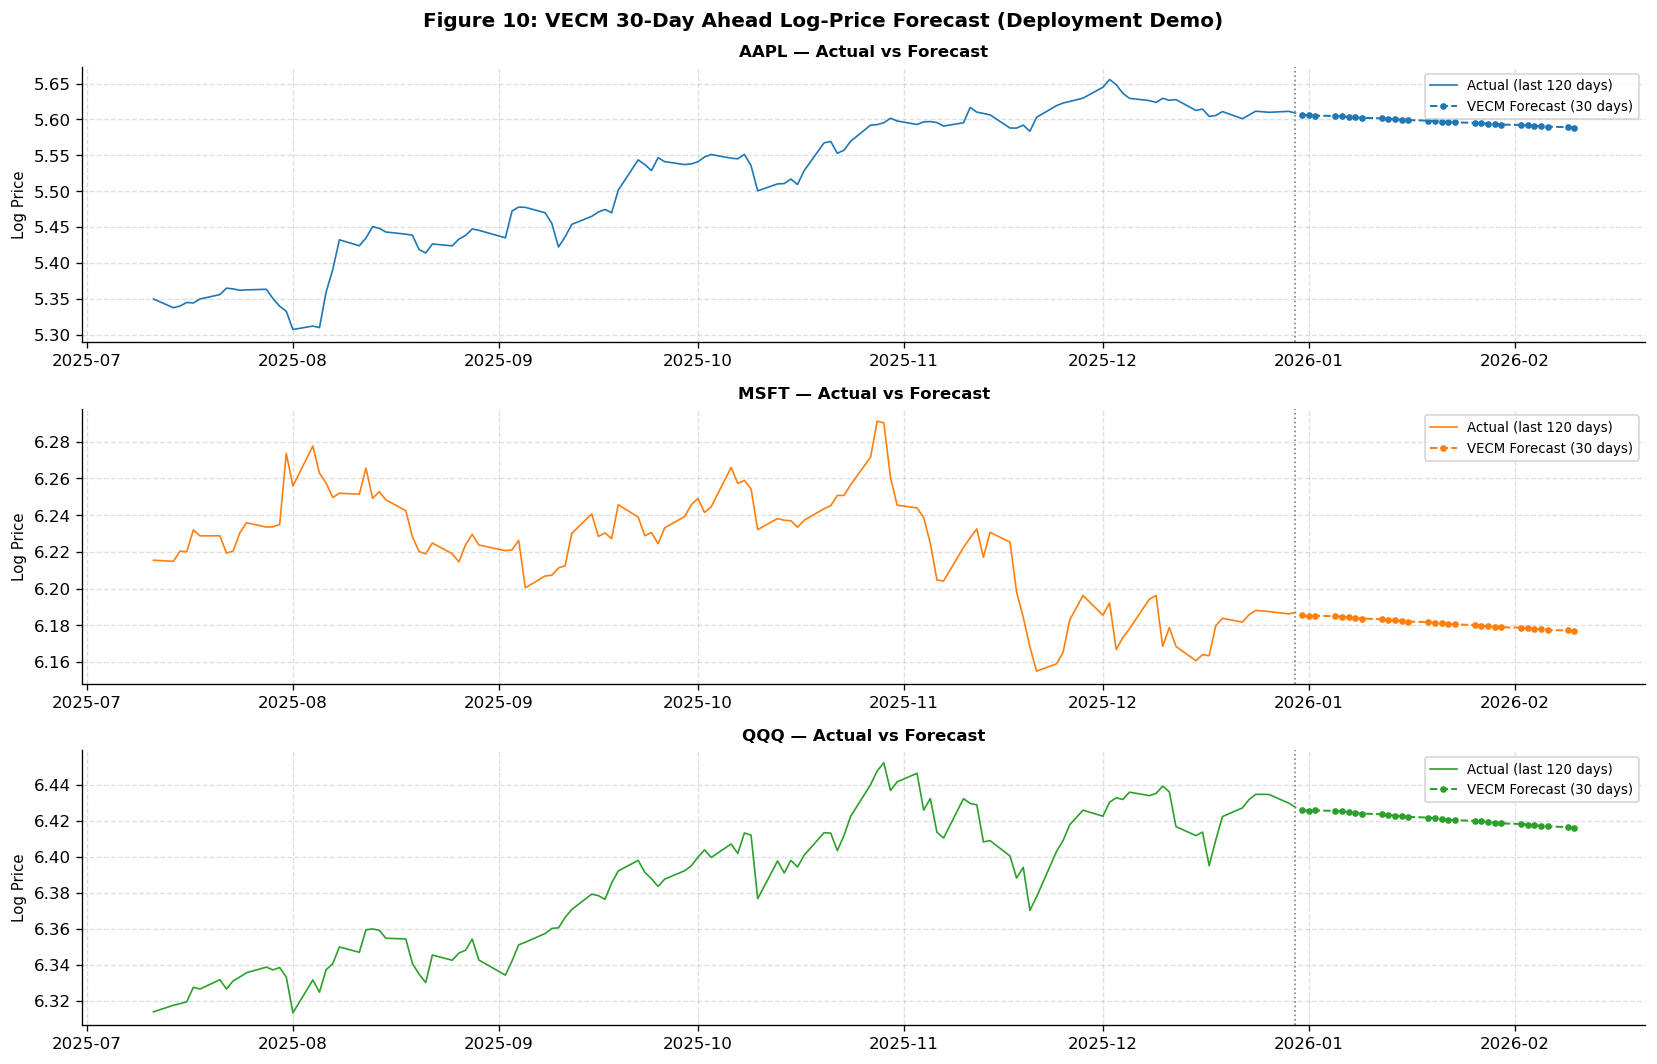


30-Day Ahead Forecasted Log-Prices:
            AAPL_fcst  MSFT_fcst  QQQ_fcst
2025-12-31     5.6068     6.1854    6.4262
2026-01-01     5.6057     6.1848    6.4256
2026-01-02     5.6054     6.1851    6.4258
2026-01-05     5.6048     6.1849    6.4256
2026-01-06     5.6042     6.1847    6.4252
2026-01-07     5.6035     6.1843    6.4249
2026-01-08     5.6029     6.1840    6.4245
2026-01-09     5.6022     6.1836    6.4241
2026-01-12     5.6016     6.1833    6.4237
2026-01-13     5.6009     6.1830    6.4233
2026-01-14     5.6003     6.1827    6.4229
2026-01-15     5.5997     6.1823    6.4226
2026-01-16     5.5990     6.1820    6.4222
2026-01-19     5.5984     6.1817    6.4218
2026-01-20     5.5978     6.1814    6.4215
2026-01-21     5.5971     6.1811    6.4211
2026-01-22     5.5965     6.1808    6.4207
2026-01-23     5.5959     6.1804    6.4204
2026-01-26     5.5953     6.1801    6.4200
2026-01-27     5.5947     6.1798    6.4197
2026-01-28     5.5941     6.1795    6.4193
2026-01-29     5.

In [54]:
# ── 30-Step Ahead VECM Forecast ───────────────────────────────────────────────
forecast_steps = 30
forecast = vecm_result.predict(steps=forecast_steps)
forecast_df = pd.DataFrame(forecast, columns=['AAPL_fcst', 'MSFT_fcst', 'QQQ_fcst'])

# Build future date index
last_date = log_prices.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)
forecast_df.index = future_dates

# Plot last 120 days + forecast
tail_actual = log_prices.iloc[-120:]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fcst_cols = ['AAPL_fcst', 'MSFT_fcst', 'QQQ_fcst']
act_cols  = ['ln_AAPL', 'ln_MSFT', 'ln_QQQ']
labels    = ['AAPL', 'MSFT', 'QQQ']

for ax, ac, fc, color, label in zip(axes, act_cols, fcst_cols, colors, labels):
    ax.plot(tail_actual.index, tail_actual[ac], color=color, linewidth=1.0, label='Actual (last 120 days)')
    ax.plot(forecast_df.index, forecast_df[fc], color=color, linewidth=1.2,
            linestyle='--', marker='o', markersize=3, label='VECM Forecast (30 days)')
    ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.0)
    ax.set_ylabel('Log Price', fontsize=9)
    ax.set_title(f'{label} — Actual vs Forecast', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Figure 10: VECM 30-Day Ahead Log-Price Forecast (Deployment Demo)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n30-Day Ahead Forecasted Log-Prices:')
print(forecast_df.round(4))

---
## 12. Summary

| Section | Key Finding |
|---------|-------------|
| **Unit Root** | ln(AAPL), ln(MSFT), ln(QQQ) are all I(1); first differences are I(0) |
| **Cointegration** | Johansen trace & max-eigenvalue tests confirm at least 1 cointegrating vector |
| **β (Cointegrating Vector)** | Defines the stable long-run linear combination of the three log-prices |
| **α (Adjustment Speed)** | AAPL adjusts fastest; QQQ adjusts slowest — sector leader vs. index dynamics |
| **Residuals** | Non-normal, ARCH effects present; short-run dynamics well-captured |
| **Deployment** | Statistical arbitrage, portfolio risk monitoring, conditional forecasting |

---

## References

1. Engle, R. F., & Granger, C. W. J. (1987). Co-integration and error correction: Representation, estimation, and testing. *Econometrica*, 55(2), 251–276.
2. Johansen, S. (1991). Estimation and hypothesis testing of cointegration vectors in Gaussian vector autoregressive models. *Econometrica*, 59(6), 1551–1580.
3. Hamilton, J. D. (1994). *Time Series Analysis*. Princeton University Press.
4. Tsay, R. S. (2010). *Analysis of Financial Time Series* (3rd ed.). Wiley.
5. Yahoo Finance. (2025). Apple Inc. (AAPL) Historical Data. https://finance.yahoo.com/quote/AAPL/history/
6. Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*.
